# Wavelength-Dependent Calibration (HK)

Optimizes all 4 detector parameters (scatter_length, wall_reflection_rate,
sensor_reflection_rate, absorption_length) at different laser wavelengths. The "true"
values for scatter and absorption come from the water medium physics at each
wavelength. This tests whether the optimizer can recover all parameters
simultaneously, and how identifiability varies with wavelength — see
`good_notebooks/calibration/wavelength_calibration_findings.md` for the SK-like
version of this experiment and why some wavelengths are more degenerate than others
(scatter/absorption length vs detector size).

The GPU work (5 independent Adam optimizations, ~500 iters each) runs in
`wavelength_calibration_job.py` as a standalone process so the CUDA context / JAX
preallocated GPU memory pool is released on exit. This notebook only loads the saved
`.npz` and plots.

In [2]:
import sys

!{sys.executable} wavelength_calibration_job.py --gpu 2 --out wavelength_calibration_results.npz

[CudaDevice(id=0)]
gpu
Detector: 19746 sensors
Optimizer: Nphot=500000, K=10, 500 iters
 wl (nm)  L_scat (m)   L_abs (m)      QE
----------------------------------------
     350        91.3       607.9   0.330
     375       128.3       551.6   0.334
     405       186.5       367.7   0.323
     450       308.3       145.7   0.265
     500       504.4        48.3   0.182

--- 350 nm ---
  True: scatter=91.3m, absorption=607.9m
  True data charge_sum=5941394
  Final: scatter=271.3 (true=91.3)  absorption=1000.9 (true=607.9)              
  Final: wall_refl=0.054 (true=0.200)  sensor_refl=0.110 (true=0.200)
  Time: 53.2s

--- 375 nm ---
  True: scatter=128.3m, absorption=551.6m
  True data charge_sum=5448223
  Final: scatter=381.2 (true=128.3)  absorption=435.3 (true=551.6)              
  Final: wall_refl=0.054 (true=0.200)  sensor_refl=0.054 (true=0.200)
  Time: 50.1s

--- 405 nm ---
  True: scatter=186.5m, absorption=367.7m
  True data charge_sum=4529615
  Final: scatter=554.0 (true=

In [3]:
import numpy as np
import matplotlib.pyplot as plt

r = np.load('wavelength_calibration_results.npz')
WAVELENGTHS = [int(w) for w in r['wavelengths']]
PARAMS = ['scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length']

results = {}
for wl in WAVELENGTHS:
    p = f'wl{wl}_'
    results[wl] = {
        'true': {f: float(r[p + 'true_' + f]) for f in PARAMS},
        'init': {f: float(r[p + 'init_' + f]) for f in PARAMS},
        'final': {f: float(r[p + 'final_' + f]) for f in PARAMS},
        'hist': {f: r[p + 'hist_' + f] for f in PARAMS},
        'losses': r[p + 'losses'],
        'runtime': float(r[p + 'runtime']),
    }
    results[wl]['true']['qe'] = float(r[p + 'true_qe'])
print(f'{len(WAVELENGTHS)} wavelengths loaded: {WAVELENGTHS}')

5 wavelengths loaded: [350, 375, 405, 450, 500]


## Summary table

In [4]:
ARROW = 'true→final'
print(f'{"wl":>5s}  {"scatter":>12s}  {"wall_refl":>12s}  {"sensor_refl":>12s}  {"absorption":>12s}  {"loss":>10s}')
print(f'{"":>5s}  {ARROW:>12s}  {ARROW:>12s}  {ARROW:>12s}  {ARROW:>12s}')
print('-' * 75)
for wl in WAVELENGTHS:
    res = results[wl]
    t, f = res['true'], res['final']
    sep = '→'
    print(f'{wl:5d}  '
          f'{t["scatter_length"]:5.0f}{sep}{f["scatter_length"]:5.1f}  '
          f'{t["wall_reflection_rate"]:5.3f}{sep}{f["wall_reflection_rate"]:.3f}  '
          f'{t["sensor_reflection_rate"]:5.3f}{sep}{f["sensor_reflection_rate"]:.3f}  '
          f'{t["absorption_length"]:5.0f}{sep}{f["absorption_length"]:5.1f}  '
          f'{res["losses"][-1]:10.6f}')

print(f'\nRelative errors:')
print(f'{"wl":>5s}  {"scatter":>8s}  {"wall":>8s}  {"sensor":>8s}  {"absorp":>8s}')
print('-' * 45)
for wl in WAVELENGTHS:
    res = results[wl]
    t, f = res['true'], res['final']
    es = abs(f['scatter_length'] - t['scatter_length']) / t['scatter_length']
    ew = abs(f['wall_reflection_rate'] - t['wall_reflection_rate']) / t['wall_reflection_rate']
    er = abs(f['sensor_reflection_rate'] - t['sensor_reflection_rate']) / t['sensor_reflection_rate']
    ea = abs(f['absorption_length'] - t['absorption_length']) / t['absorption_length']
    print(f'{wl:5d}  {es:8.3f}  {ew:8.3f}  {er:8.3f}  {ea:8.3f}')

   wl       scatter     wall_refl   sensor_refl    absorption        loss
         true→final    true→final    true→final    true→final
---------------------------------------------------------------------------
  350     91→271.3  0.200→0.054  0.200→0.110    608→1000.9    0.015641
  375    128→381.2  0.200→0.054  0.200→0.054    552→435.3    0.027887
  405    187→554.0  0.200→0.054  0.200→0.054    368→237.9    0.059410
  450    308→915.7  0.200→0.054  0.200→0.054    146→100.9    0.158386
  500    504→1498.2  0.200→0.054  0.200→0.054     48→ 37.9    0.508974

Relative errors:
   wl   scatter      wall    sensor    absorp
---------------------------------------------
  350     1.971     0.728     0.448     0.647
  375     1.970     0.728     0.732     0.211
  405     1.970     0.728     0.732     0.353
  450     1.970     0.728     0.732     0.308
  500     1.970     0.728     0.732     0.215


## Parameter convergence plots

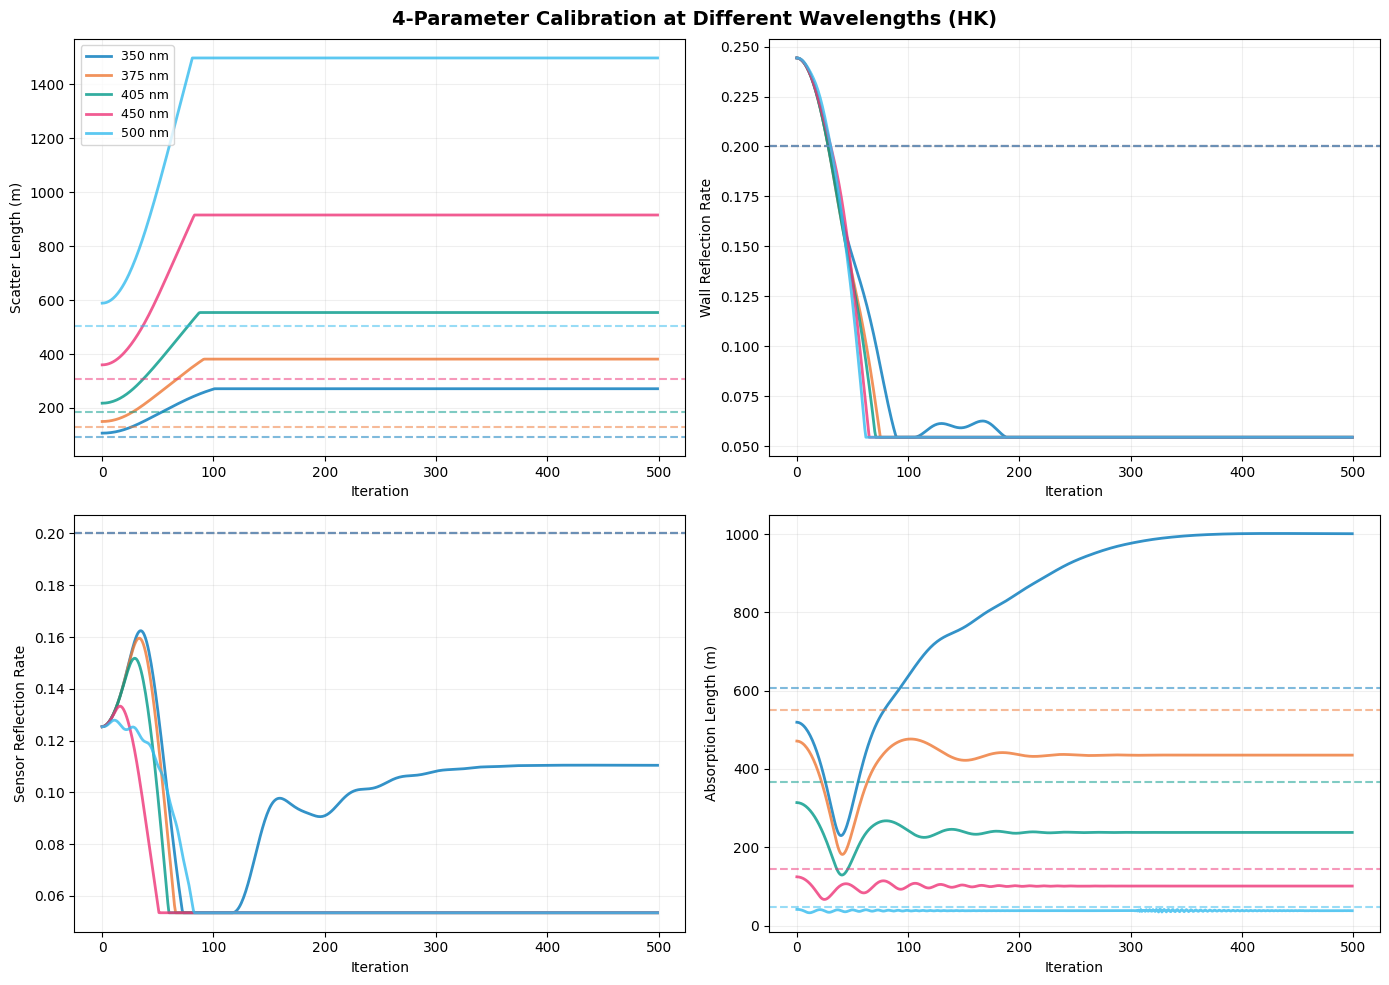

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
param_labels = ['Scatter Length (m)', 'Wall Reflection Rate', 'Sensor Reflection Rate', 'Absorption Length (m)']
colors = ['#0077BB', '#EE7733', '#009988', '#EE3377', '#33BBEE']

for pidx, (pname, plabel) in enumerate(zip(PARAMS, param_labels)):
    ax = axes[pidx // 2, pidx % 2]
    for widx, wl in enumerate(WAVELENGTHS):
        res = results[wl]
        vals = res['hist'][pname]
        ax.plot(vals, color=colors[widx], linewidth=2, alpha=0.8, label=f'{wl} nm')
        ax.axhline(y=res['true'][pname], color=colors[widx], linestyle='--', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(plabel)
    ax.grid(True, alpha=0.2)
    if pidx == 0:
        ax.legend(loc='best', fontsize=9)

plt.suptitle('4-Parameter Calibration at Different Wavelengths (HK)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Loss curves

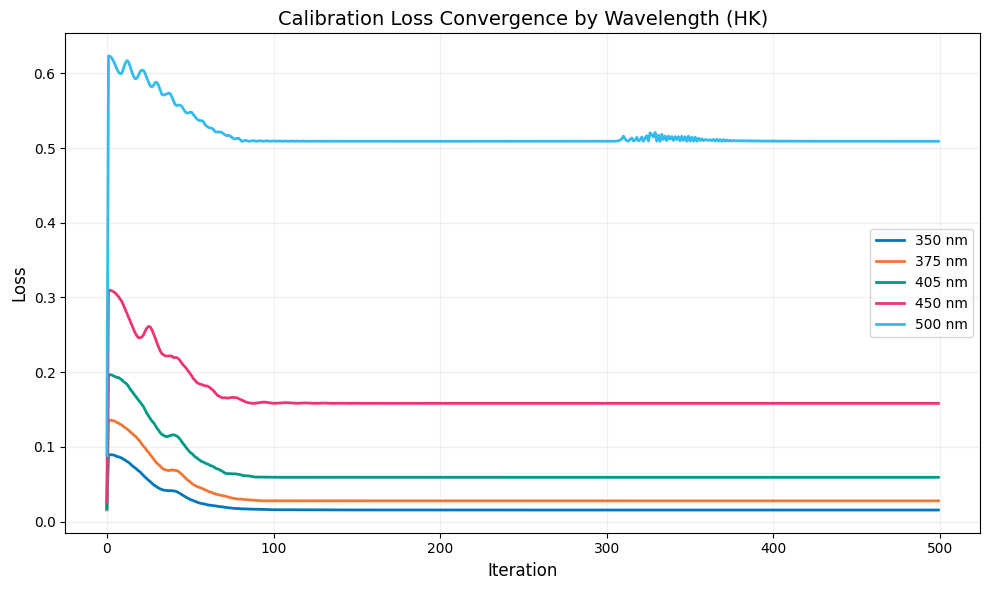

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for widx, wl in enumerate(WAVELENGTHS):
    ax.plot(results[wl]['losses'], color=colors[widx], linewidth=2, label=f'{wl} nm')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Calibration Loss Convergence by Wavelength (HK)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()